# 5. Feature Selection

The initial dataset, following the Feature Engineering stage, contains 659 variables. To ensure model robustness, prevent overfitting, and meet the performance requirements of the Siemens Smart Infrastructure environment, a 4 phase feature selection engine was implemented.

The objective is to filter out noise and retain only the signals with the highest predictive power and temporal stability.

## 5.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import sys
import os
sys.path.append(os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
import re
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import spearmanr
from src.code.class_pipeline_functions import FeatureSelection
from collections import Counter

sns.set_theme(style="whitegrid")

## 5.2 Data checks

In [2]:
data_dir = '../data/features'

train_df = pd.read_parquet(os.path.join(data_dir, 'training_subsegment_fe.parquet'))
val_df = pd.read_parquet(os.path.join(data_dir, 'validation_subsegment_fe.parquet'))

In [3]:
train_df.head()

,Anon Period,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon),China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,...,United_States_Inflation_Rate_Lag_6,United_States_Inflation_Rate_Lag_12,United_States_Inflation_Rate_Rolling_Mean_3,United_States_Inflation_Rate_Rolling_Std_3,United_States_Inflation_Rate_Rolling_Mean_12,United_States_Inflation_Rate_Rolling_Std_12,United_States_Inflation_Rate_YoY_Diff,United_States_Inflation_Rate_YoY_Ratio,United_States_Inflation_Rate_Momentum_3_12,United_States_Inflation_Rate_Anomaly_12
0,1,SSI027,SSI02710,SSI02710,0.0,-390277.0,0.7,263.09,18201.7,32730.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,SSI027,SSI02710,SSI02710,0.0,334.0,0.9,263.23,18201.7,32730.0,...,NaN,NaN,4.200000,NaN,4.200000,NaN,NaN,NaN,0.000000,NaN
2,3,SSI027,SSI02710,SSI02710,0.0,334.0,0.9,280.30,18201.7,32730.0,...,NaN,NaN,4.600000,0.565685,4.600000,0.565685,NaN,NaN,0.000000,0.707107
3,4,SSI027,SSI02710,SSI02710,0.0,1811758.0,1.3,281.28,18201.7,53544.1,...,NaN,NaN,4.866667,0.611010,4.866667,0.611010,NaN,NaN,0.000000,0.872872
4,5,SSI027,SSI02710,SSI02710,0.0,80112.0,1.2,293.17,18201.7,53544.1,...,NaN,NaN,5.266667,0.230940,5.000000,0.565685,NaN,NaN,0.266667,0.707107


In [4]:
val_df.head()

,Anon Period,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon),China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,...,United_States_Inflation_Rate_Lag_6,United_States_Inflation_Rate_Lag_12,United_States_Inflation_Rate_Rolling_Mean_3,United_States_Inflation_Rate_Rolling_Std_3,United_States_Inflation_Rate_Rolling_Mean_12,United_States_Inflation_Rate_Rolling_Std_12,United_States_Inflation_Rate_YoY_Diff,United_States_Inflation_Rate_YoY_Ratio,United_States_Inflation_Rate_Momentum_3_12,United_States_Inflation_Rate_Anomaly_12
0,44,SSI027,SSI02710,SSI02710,NaN,NaN,0.3,311.88,18743.8,88862.8,...,3.3,3.1,2.500000,0.100000,3.033333,0.367630,-0.5,0.838710,-0.533333,-1.178723
1,45,SSI027,SSI02710,SSI02710,NaN,NaN,0.4,335.65,18743.8,88862.8,...,3.0,3.4,2.566667,0.152753,3.000000,0.378994,-0.7,0.794118,-0.433333,-0.791570
2,48,SSI027,SSI02710,SSI02710,NaN,NaN,0.5,313.13,NaN,14255.6,...,2.4,3.5,2.900000,0.100000,2.916667,0.348590,-0.7,0.800000,-0.016667,-0.334681
3,43,SSI027,SSI02710,SSI0271002,NaN,NaN,0.2,308.86,18743.8,88862.8,...,3.4,3.2,2.600000,0.264575,3.083333,0.343335,-0.8,0.750000,-0.483333,-1.990283
4,44,SSI027,SSI02710,SSI0271002,NaN,NaN,0.3,311.88,18743.8,88862.8,...,3.3,3.1,2.500000,0.100000,3.033333,0.367630,-0.5,0.838710,-0.533333,-1.178723


In [5]:
id_cols = ['Anon Period', 'TGL Business Unit', 'TGL Business Segment', 'TGL Business Subsegment']
target_cols = ['Orders cons. (anon)', 'Revenue cons. (anon)']

In [6]:
main_target = 'Revenue cons. (anon)'

X_train = train_df.drop(columns=id_cols + target_cols)
y_train = train_df[main_target].fillna(0) # filling the NaNs

## 5.3 Feature Selection Strategy

The feature selection engine is designed to distill high-dimensional data into a robust set of predictors while maintaining business relevance. From an initial pool of **659 variables**, the system performs a four-stage distillation process optimized for Siemens SI sales data.

---

### Phase 1 & 2: Family-Based Diversity & Intra-Family Pruning
This phase is engineered to preserve a balanced representation across different data families (Macroeconomic, Orders, and Revenue).
* **NaN-Safe Spearman Ranking:** Rank correlation is calculated using non-NaN row alignment. This is critical for industrial data where structural NaNs appear in the early periods of new product histories.
* **Per-Family Top-K Selection:** To prevent dominant variable groups from crowding out other signals, the engine selects the best $K$ lags *within each family* (e.g., best Macro lags, best Revenue lags).
* **Intra-Family Pairwise Pruning:** Redundancy checks (Pearson correlation $> 0.90$) are performed within each family independently. This ensures that a Revenue signal isn't discarded simply because it correlates with an Orders signal, preserving multi-dimensional business perspectives.

---

### Phase 3: Ensemble Consensus Voting
The engine utilizes a "democratic" voting system between two distinct mathematical models to find the "elite" predictors.

1. **LassoCV (Linear Logic):**
    * **Dual Scaling:** A `RobustScaler` is applied to both $X$ and $y$. Normalizing the target (Revenue in millions) is essential to keep the Lasso penalty space stable and avoid zeroing out valid features prematurely.
    * **Temporal Cross-Validation:** Uses a `TimeSeriesSplit` (expanding window) to validate the model. This respects the chronological order of sales data, avoiding the look-ahead bias inherent in standard K-Fold shuffling.

2. **Random Forest (Non-linear Logic):**
    * **Cumulative Importance Threshold:** Instead of a fixed count, the model uses an adaptive threshold (default 90%). It retains the minimum number of features required to reach 90% of the total Gini importance, allowing the selection to expand or contract based on the actual signal strength of the segment.

---

### Phase 4: Structural Rescue & Reproducibility
The final phase aligns the statistical output with Siemens S&OP business rules and technical stability.
* **Rescue Logic:** Key structural drivers—such as **Seasonality**
* **Stable Ordering:** The final feature set is re-indexed to match the original input column order, ensuring that model training is reproducible and that feature importance interpretations remain consistent across different sessions.

---

### Final Summary
This multistage approach results in a highly distilled, high-signal dataset:
* **Initial Pool:** 659 features.
* **Filtering Efficiency:** ~84% noise reduction.
* **Final Set:** ~104 features


In [7]:
selector = FeatureSelection(
    horizon=1,
    lag_top_k=2,       # top-2 lags per variable family (intra-family Pearson then prunes to 1 if correlated)
    corr_threshold=0.95, # lower → more aggressive redundancy removal in Phase 2+3
    min_votes=1,        # union of Lasso + RF (with min_votes=2 only 15 features survived)
    rf_cum_threshold=0.90,        # selects 90pp by importance 
)

selector.fit(X_train, y_train)
selector.get_selection_report()

X_train_selected = selector.transform(X_train)

X_val_features = val_df.drop(columns=id_cols + target_cols)
X_val_selected = selector.transform(X_val_features)

print(f"Original features: {X_train.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

Feature Selection Report

> Phase 1 & 2: Correlation: 267 variables removed
  Examples: China_Core_Inflation_Rate_Lag_1, China_Core_Inflation_Rate_Lag_3, China_Core_Inflation_Rate_Rolling_Mean_12, China_Core_Inflation_Rate_YoY_Ratio, China_GDP_Lag_1, China_GDP_Lag_12, China_GDP_Rolling_Std_12, China_GDP_YoY_Ratio, China_GDP_from_Construction_Lag_1, China_GDP_from_Construction_Lag_6...

> Phase 3: Voting: 333 variables removed
  Examples: China_Core_Inflation_Rate, China_Core_Inflation_Rate_Anomaly_12, China_Core_Inflation_Rate_Lag_12, China_Core_Inflation_Rate_Lag_6, China_Core_Inflation_Rate_Momentum_3_12, China_Core_Inflation_Rate_Rolling_Mean_3, China_Core_Inflation_Rate_Rolling_Std_12, China_Core_Inflation_Rate_Rolling_Std_3, China_Core_Inflation_Rate_YoY_Diff, China_Exports...

> Structural Rescue: 45 variables rescued (added back)
  Examples: Month, Month_cos, Month_sin, Orders cons. (anon)_Months_Since_Last_Nonzero, Orders cons. (anon)_Parent_Lag_12_TGL Business Unit, Orders con

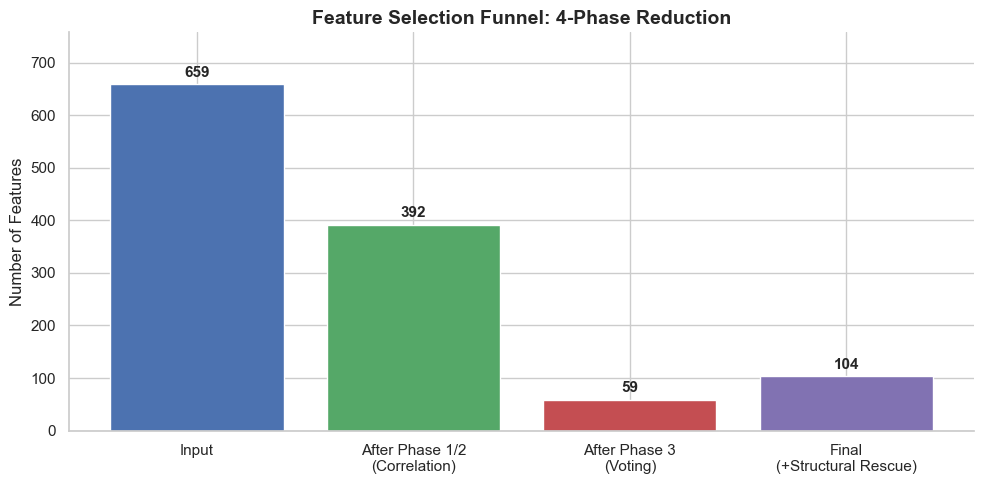

In [8]:
# feature reduction funnel visualization
phases = ['Input', 'After Phase 1/2\n(Correlation)', 'After Phase 3\n(Voting)', 'Final\n(+Structural Rescue)']
counts = [
    len(selector.input_features_),
    len(selector.input_features_) - len(selector.removal_log_.get('Phase 1 & 2: Correlation', [])),
    len(selector.input_features_) - len(selector.removal_log_.get('Phase 1 & 2: Correlation', [])) - len(selector.removal_log_.get('Phase 3: Voting', [])),
    len(selector.selected_features_),
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(phases, counts, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
ax.bar_label(bars, fmt='%d', padding=3, fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Features')
ax.set_title('Feature Selection Funnel: 4-Phase Reduction', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts) * 1.15)
sns.despine()
plt.tight_layout()
plt.show()


## 5.4 Core Feature Families Visualization

To ensure the selected features generalize beyond any single business subsegment, we run the full 4 phase feature selection pipeline independently across multiple subsegments and measure the **feature persistence**. The goal is to identify a **universal feature set**, predictors that are consistently selected regardless of the subsegment's specific demand pattern.

**Methodology:**
1. The `FeatureSelection` pipeline is fitted independently on each subsegment (minimum 24 months of history required).
2. Features selected across all runs are aggregated, and their **selection frequency** is computed as a percentage of successful subsegment fits.
3. **Universal features** are defined as those appearing in ≥70% of subsegments, ensuring broad cross-segment relevance.
4. An **elite subset** (≥95% frequency) is further extracted and categorized into interpretable business families (Macroeconomic, Hierarchy, Seasonality, Pricing, Autoregressive, etc.) to visualize the compositional balance of the core signal.

This analysis validates that the feature selection pipeline produces a stable, interpretable predictor set rather than overfitting to the idiosyncrasies of individual subsegments.


In [9]:
all_selected_features = []
subsegments_to_test = train_df['TGL Business Subsegment'].unique()[:15] #checking for 15 subsegments, 6 processed

for seg in subsegments_to_test:
    mask = train_df['TGL Business Subsegment'] == seg
    X_seg = X_train[mask]
    y_seg = y_train[mask]
    
    if len(X_seg) < 24: 
        continue
        
    sel = FeatureSelection(horizon=1, lag_top_k=2, corr_threshold=0.90, min_votes=1)
    
    try:
        sel.fit(X_seg, y_seg)
        all_selected_features.append(sel.selected_features_)
    except:
        continue

flat_list = [item for sublist in all_selected_features for item in sublist]
feature_freq = Counter(flat_list)

# universal features are the ones present in 70% of the cases
threshold = len(all_selected_features) * 0.7
universal_features = [f for f, count in feature_freq.items() if count >= threshold]

print(f"\nTotal processed subsegments: {len(all_selected_features)}")
print(f"Universal features found: {len(universal_features)}")
print(universal_features)


Total processed subsegments: 6
Universal features found: 97
['China_Exports', 'China_Industrial_Production', 'China_Steel_Production', 'France_Exports', 'Germany_Steel_Production', 'Japan_Industrial_Production', 'Switzerland_Exports', 'United_Kingdom_Industrial_Production_Mom', 'United_States_Industrial_Production', 'Month', 'Quarter', 'Month_sin', 'Month_cos', 'Quarter_sin', 'Quarter_cos', 'Orders cons. (anon)_Rolling_Mean_3', 'Orders cons. (anon)_Trend_Slope_6', 'Orders cons. (anon)_Momentum_6_12', 'Orders cons. (anon)_Months_Since_Last_Nonzero', 'Orders cons. (anon)_Zero_Share_6', 'Orders cons. (anon)_Zero_Share_12', 'Revenue cons. (anon)_Lag_24', 'Revenue cons. (anon)_Rolling_Mean_3', 'Revenue cons. (anon)_Rolling_Std_3', 'Revenue cons. (anon)_Rolling_Std_6', 'Revenue cons. (anon)_Rolling_Std_12', 'Revenue cons. (anon)_Trend_Slope_12', 'Revenue cons. (anon)_Momentum_6_12', 'Revenue cons. (anon)_YoY_Diff', 'Revenue cons. (anon)_Months_Since_Last_Nonzero', 'Revenue cons. (anon)_Zero

**Result:** Out of 15 candidate subsegments, 6 met the minimum history requirement (≥24 months). From those 6 independent runs, 97 features were consistently selected in at least 70% of cases, indicating a strong core signal across diverse demand profiles.


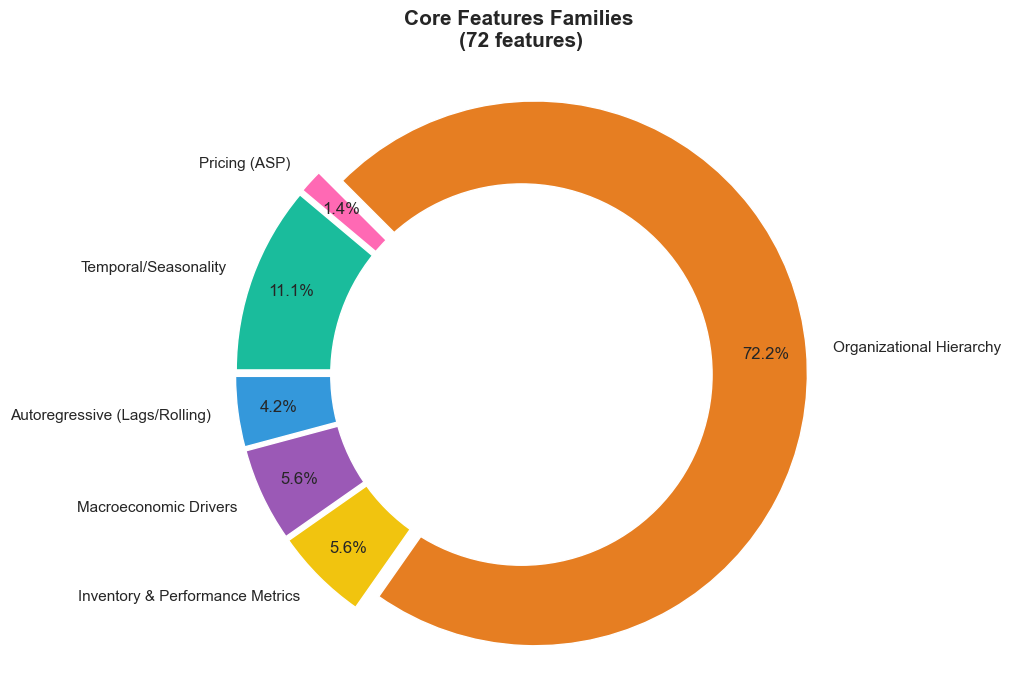

In [10]:
n_real_success = len(all_selected_features) 

def categorize(feature):
    # macro indicators
    countries = ['China', 'Germany', 'France', 'United_States', 'Italy', 'Japan', 'Switzerland', 'United_Kingdom']
    if any(ctry in feature for ctry in countries): 
        return 'Macroeconomic Drivers'
    
    # hierarchy 
    if 'Parent' in feature or 'Share_of_Parent' in feature: 
        return 'Organizational Hierarchy'
    
    # calendar & seasonality
    if any(kw in feature for kw in ['Month', 'Quarter', 'sin', 'cos']): 
        return 'Temporal/Seasonality'
    
    # pricing dynamics
    if 'ASP' in feature: 
        return 'Pricing (ASP)'
    
    # inventory & sales performance
    if any(kw in feature for kw in ['Zero_Share', 'Months_Since_Last_Nonzero', 'Nonzero_Count', 'CV_12', 'Momentum']):
        return 'Inventory & Performance Metrics'
    
    # autoregressive features 
    if any(kw in feature for kw in ['Lag_', 'Rolling_', 'Trend_Slope']):
        return 'Autoregressive (Lags/Rolling)'
    
    # fallback
    return 'Other Internal Dynamics'

if n_real_success == 0:
    print("Error.")
else:
    full_freq = pd.DataFrame.from_dict(feature_freq, orient='index', columns=['count'])
    full_freq['percentage'] = (full_freq['count'] / n_real_success) * 100
    full_freq = full_freq.sort_values('percentage', ascending=False)

    threshold_elite = 95 
    elite_features = full_freq[full_freq['percentage'] >= threshold_elite].index

    if len(elite_features) == 0:
        print(f"No feature reached a value of {threshold_elite}%.")
        print(f"The max is {full_freq['percentage'].max():.1f}%.")
    else:
        # categorizing features into families
        elite_categories = [categorize(f) for f in elite_features]
        elite_counts = Counter(elite_categories)

        # graph
        plt.figure(figsize=(10, 7))
        colors = ['#1abc9c', '#3498db', '#9b59b6', '#f1c40f', '#e67e22', '#FF69B4']
        
        plt.pie(
            elite_counts.values(), 
            labels=elite_counts.keys(), 
            autopct='%1.1f%%', 
            startangle=140, 
            colors=colors[:len(elite_counts)],
            pctdistance=0.85,
            explode=[0.05] * len(elite_counts)
        )

        centre_circle = plt.Circle((0,0), 0.70, fc='white')
        fig = plt.gcf()
        fig.gca().add_artist(centre_circle)

        plt.title(f'Core Features Families \n({len(elite_features)} features)', 
                  fontsize=15, fontweight='bold', pad=20)
        plt.axis('equal') 
        plt.tight_layout()
        plt.show()

The analysis of the **Elite Core (72 Features)**: those consistently selected across more than 95% of all business subsegments, reveals a powerful and highly stable predictive structure. This "Golden Subset" provides the mathematical evidence required to transition from a complex 659-feature space to a streamlined forecasting engine:

* **The Dominance of Institutional Anchoring (72.2%):** The overwhelming majority of the universal signal is derived from **Organizational Hierarchy** (Parent Unit and Business Segment metrics). This proves that individual subsegments do not behave as isolated entities; instead, they are strongly "anchored" to the performance and strategic direction of their parent business units. For Management, this implies that ensuring high data quality at the Business Unit level yields the highest dividends for local accuracy.

* **Temporal Rhythms as a Global Pulse (11.1%):** Seasonality and calendar-based features represent the second most stable pillar. This suggests that the fiscal cycles and quarterly closing dynamics of Siemens act as a universal metronome across the entire portfolio, regardless of the specific product line.

* **The Idiosyncrasy of Macro and Price (7.0% combined):** Interestingly, **Macroeconomic Drivers** and **Pricing (ASP)** represent a small fraction of the *universal* core. This does not mean they are unimportant, but rather that their impact is highly specific to certain subsegments. While the hierarchy is a "Global Rule," market indicators act as "Local Adjustments" that must be selected on a case-by-case basis.

## 5.5 Exporting the datasets

In [11]:
# Save the feature-selected datasets
output_dir = '../data/features'

train_df_selected = pd.concat([train_df[id_cols + target_cols].reset_index(drop=True),
                                X_train_selected.reset_index(drop=True)], axis=1)
val_df_selected   = pd.concat([val_df[id_cols + target_cols].reset_index(drop=True),
                                X_val_selected.reset_index(drop=True)],   axis=1)

train_df_selected.to_parquet(os.path.join(output_dir, 'training_subsegment_fs.parquet'), index=False)
val_df_selected.to_parquet(os.path.join(output_dir,   'validation_subsegment_fs.parquet'), index=False)

print(f"Saved training:   {train_df_selected.shape}")
print(f"Saved validation: {val_df_selected.shape}")

Saved training:   (4237, 110)
Saved validation: (715, 110)
